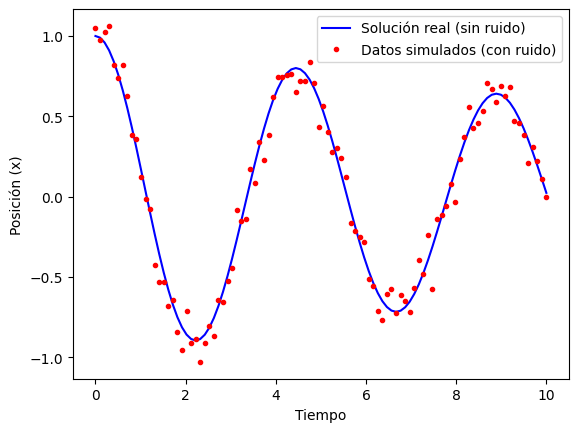

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def oscilador(y, t, m, c, k):
    x, v = y  # y[0] = posición, y[1] = velocidad
    dxdt = v
    dvdt = (-c * v - k * x) / m
    return [dxdt, dvdt]

# Parámetros reales (desconocidos en la práctica)
m_true, c_true, k_true = 1.0, 0.1, 2.0

# Condiciones iniciales y tiempo
y0 = [1.0, 0.0]  # x(0)=1, v(0)=0
t = np.linspace(0, 10, 100)

# Solución exacta (sin ruido)
sol = odeint(oscilador, y0, t, args=(m_true, c_true, k_true))
x_true = sol[:, 0]

# Añadir ruido gaussiano
np.random.seed(42)
ruido = 0.1 * np.random.normal(size=len(t))
x_ruido = x_true + ruido

# Graficar
plt.plot(t, x_true, 'b-', label='Solución real (sin ruido)')
plt.plot(t, x_ruido, 'r.', label='Datos simulados (con ruido)')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Posición (x)')
plt.show()

In [3]:
def costo(params, t, x_ruido):
    m, c, k = params
    sol = odeint(oscilador, y0, t, args=(m, c, k))
    x_modelo = sol[:, 0]
    return np.sum((x_modelo - x_ruido)**2)

In [4]:
def gradiente_adaptativo(f, x, h_initial=1e-3, epsilon=1e-6, max_iter=20):
    # Basado en el Algoritmo 2.1 del paper
    h = h_initial
    grad = np.zeros_like(x)
    for i in range(len(x)):
        xi = x.copy()
        def f_theta(h_val):
            xi[i] = x[i] + h_val
            f_plus = f(xi)
            xi[i] = x[i] - h_val
            f_minus = f(xi)
            return (f_plus - f_minus) / (2 * h_val)
        
        # Búsqueda de h óptimo (simplificado)
        h_opt = h_initial
        for _ in range(max_iter):
            grad_est = f_theta(h_opt)
            if np.abs(grad_est) < epsilon:
                break
            h_opt *= 0.5  # Ajuste heurístico (mejorar con bisección como en el paper)
        
        grad[i] = f_theta(h_opt)
    return grad

In [5]:
import numpy as np
from scipy.optimize import minimize

# Parámetros iniciales (adivinanza)
params_iniciales = np.array([0.5, 0.05, 1.5])

# Optimización
resultado = minimize(
    fun=costo,
    x0=params_iniciales,
    args=(t, x_ruido),
    method='L-BFGS-B',
    jac=lambda params: gradiente_adaptativo(lambda p: costo(p, t, x_ruido), params),
    bounds=[(0.1, 10), (0, 1), (0.1, 5)]  # Restricciones físicas
)

print("Parámetros estimados:", resultado.x)
print("Parámetros reales:", [m_true, c_true, k_true])

TypeError: <lambda>() takes 1 positional argument but 3 were given

In [6]:
from scipy.optimize import minimize

# Función de costo (ya definida)
def costo(params, t, x_ruido):
    m, c, k = params
    sol = odeint(oscilador, y0, t, args=(m, c, k))
    x_modelo = sol[:, 0]
    return np.sum((x_modelo - x_ruido)**2)

# Gradiente adaptativo (versión simplificada del paper)
def gradiente_adaptativo(f, x, h_initial=1e-3, epsilon=1e-6, max_iter=20):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        h = h_initial
        for _ in range(max_iter):
            x_plus = x.copy()
            x_plus[i] += h
            f_plus = f(x_plus)
            
            x_minus = x.copy()
            x_minus[i] -= h
            f_minus = f(x_minus)
            
            grad_est = (f_plus - f_minus) / (2 * h)
            if np.abs(grad_est) < epsilon:
                break
            h *= 0.5  # Ajuste heurístico (mejorar con bisección como en el paper)
        grad[i] = grad_est
    return grad

# Optimización
params_iniciales = np.array([0.5, 0.05, 1.5])
resultado = minimize(
    fun=lambda params: costo(params, t, x_ruido),  # Función de costo con args
    x0=params_iniciales,
    method='L-BFGS-B',
    jac=lambda params: gradiente_adaptativo(lambda p: costo(p, t, x_ruido), params),  # Gradiente
    bounds=[(0.1, 10), (0, 1), (0.1, 5)]
)

print("Parámetros estimados:", resultado.x)
print("Parámetros reales:", [m_true, c_true, k_true])

Parámetros estimados: [0.73733447 0.07698681 1.47503009]
Parámetros reales: [1.0, 0.1, 2.0]


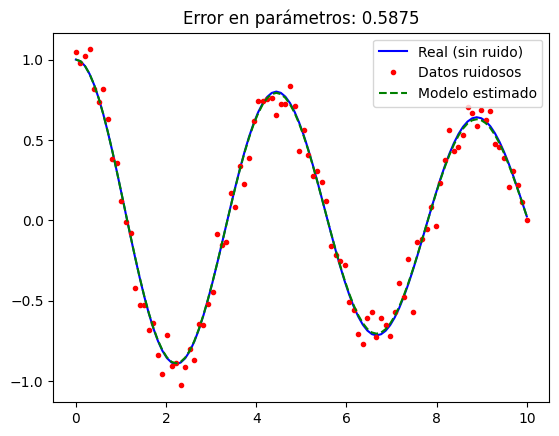

In [7]:
sol_estimada = odeint(oscilador, y0, t, args=tuple(resultado.x))
x_estimada = sol_estimada[:, 0]

plt.plot(t, x_true, 'b-', label='Real (sin ruido)')
plt.plot(t, x_ruido, 'r.', label='Datos ruidosos')
plt.plot(t, x_estimada, 'g--', label='Modelo estimado')
plt.legend()
plt.title(f"Error en parámetros: {np.linalg.norm(resultado.x - [m_true, c_true, k_true]):.4f}")
plt.show()

In [1]:
for i in range(1):
    print(i)

0


In [2]:
import numpy as np
print(np.triu([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], 1))


[[0 2 3]
 [0 0 6]
 [0 0 0]
 [0 0 0]]
